# 02. 데이터 전처리 — 전후 비교

`data/raw_sample.csv`를 정제하고 전/후를 비교한다. 산출물: `data/{train,val,test}.csv`
정제 규칙은 `01_download_data.ipynb`의 노이즈 진단(`output/01_noise_diagnosis_v2.*`) 결과에 근거한다.
표는 `output/02_*.csv`, 그래프는 `output/02_*.png`로 저장한다.

**정제 규칙** (`src.data.pipeline`):

| 단계 | 내용 | 이유 (01 진단 근거) |
|---|---|---|
| 기본 정제 | 결측·빈문자열·중복 제거, 라벨 1/-1 → 1/0 | 학습 불가능한 행 제거 |
| HTML 엔티티 복원 | `&quot;`→`"`, `&amp;`→`&` | 약 2%가 이스케이프된 채 저장됨 |
| Early Access 제거 | 접두 문구 "Early Access Review" 삭제 | 약 16%에 자동 삽입된 문구, 감성과 무관 |
| BBCode 제거 | `[h1]`, `[b]`, `[spoiler]` 등 | Steam 마크업은 감성과 무관 |
| URL 제거 | `http://...`, `www...` | 어휘 낭비 |
| 반복문자 축약 | `soooooo`→`soo`, `♥♥♥♥`→`♥♥` | 같은 의미 토큰 통합 |
| 구두점 분리 | `game.`→`game .` | LSTM 공백 토크나이저의 어휘 낭비 방지 |
| 기호-only 제거 | 영숫자 없는 리뷰(이모지·기호만) 삭제 | 감성 신호 없음 |
| 최소 길이 필터 | 3단어 미만 제거 | `"gud"`, `"+"` 같은 무신호 리뷰 제거 |

In [28]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
from src.config import DATA_DIR, OUTPUT_DIR, RANDOM_SEED
from src.data.pipeline import clean_reviews, split_data, normalize_text
from src.models.dataset import build_vocab

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

raw = pd.read_csv(DATA_DIR / "raw_sample.csv")
print(f"원본: {len(raw):,}건")

원본: 20,000건


## 전/후 예시 — 노이즈가 실제로 어떻게 정리되는가

In [29]:
texts = raw["review_text"].astype(str)
noisy_mask = (texts.str.contains(
                  r"\[/?[a-zA-Z0-9*=]+\]|https?://|(.)\1{3,}"
                  r"|&(?:quot|amp|lt|gt|#\d+);|^\s*Early Access Review",
                  regex=True, case=False)
              & (texts.str.split().str.len() < 60))
examples = texts[noisy_mask].head(8)

pd.set_option("display.max_colwidth", 120)
compare = pd.DataFrame({"전 (원본)": examples.values,
                        "후 (정제)": [normalize_text(t) for t in examples]})
compare.to_csv(OUTPUT_DIR / "02_before_after_examples_v2.csv", index=False, encoding="utf-8-sig")
compare

/var/folders/lk/_s9hm0fx6kq9cbqvf92w9yd00000gn/T/ipykernel_94981/2462298187.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  noisy_mask = (texts.str.contains(


,전 (원본),후 (정제)
0,"From a technical standpoint, this game is a massive piece of ♥♥♥♥ (i.e. obvious laziness on Gearbox's side, tons of ...","From a technical standpoint , this game is a massive piece of ♥♥ (i . e . obvious laziness on Gearbox's side , tons ..."
1,Early Access Review,Early Access Review
2,Early Access Review,Early Access Review
3,Theres seriously no reason why you don't have this game......,Theres seriously no reason why you don't have this game . .
4,good game........ if your playing as a human.... have fun lol,good game . . if your playing as a human . . have fun lol
5,very cute and innovative and a great way to spend a couple hours! can't wait for the next one! &lt;3,very cute and innovative and a great way to spend a couple hours ! can't wait for the next one ! &lt;3
6,Early Access Review,Early Access Review
7,Early Access Review,Early Access Review


## 전/후 통계 비교 — 데이터 크기, 어휘 크기, 평균 길이

In [30]:
before = clean_reviews(raw, "review_text", "review_score")          # 기본 정제만
after = clean_reviews(raw, "review_text", "review_score",
                      normalize=True, min_words=3)                  # 정규화 + 길이 필터

stats = pd.DataFrame({
    "리뷰 수": [len(before), len(after)],
    "어휘 크기 (min_freq=2)": [len(build_vocab(before["text"].tolist())),
                               len(build_vocab(after["text"].tolist()))],
    "평균 단어 수": [before["text"].str.split().str.len().mean(),
                     after["text"].str.split().str.len().mean()],
    "긍정 비율": [before["label"].mean(), after["label"].mean()],
}, index=["전처리 전", "전처리 후"]).round(3)
stats.to_csv(OUTPUT_DIR / "02_preprocess_stats_v2.csv", encoding="utf-8-sig")
stats

,리뷰 수,어휘 크기 (min_freq=2),평균 단어 수,긍정 비율
전처리 전,16653,26163,65.666,0.821
전처리 후,16426,19340,74.084,0.821


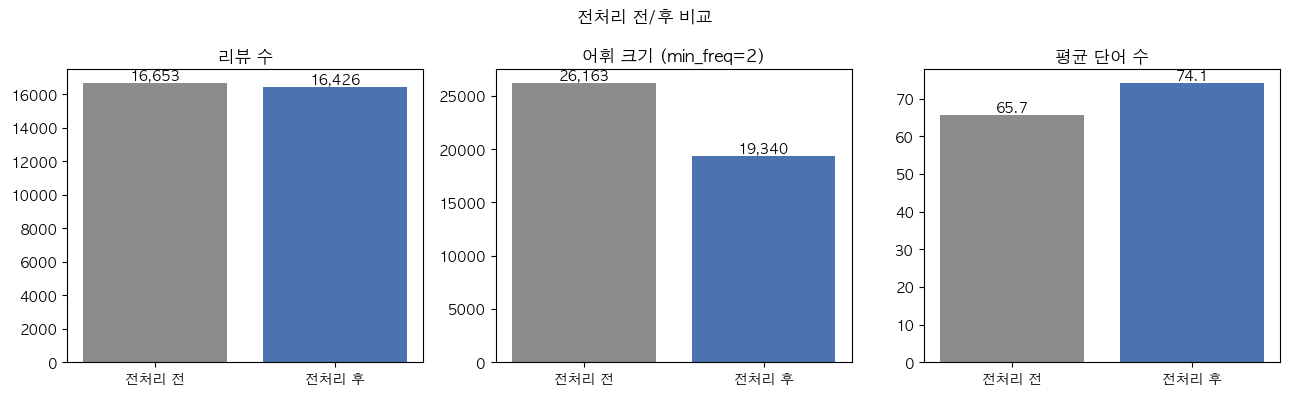

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, ["리뷰 수", "어휘 크기 (min_freq=2)", "평균 단어 수"]):
    vals = stats[col]
    ax.bar(vals.index, vals.values, color=["#8c8c8c", "#4c72b0"])
    ax.set_title(col)
    for i, v in enumerate(vals.values):
        ax.text(i, v, f"{v:,.1f}" if v % 1 else f"{int(v):,}", ha="center", va="bottom")
plt.suptitle("전처리 전/후 비교")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "02_preprocess_stats_v2.png", dpi=150, bbox_inches="tight")
plt.show()

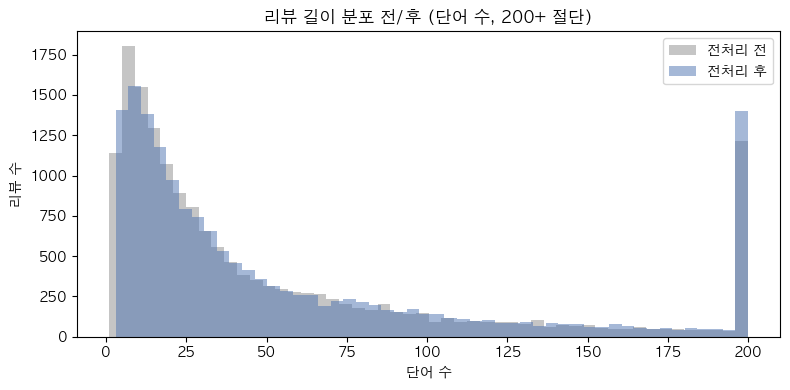

In [32]:
# 리뷰 길이 분포 전/후 오버레이
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(before["text"].str.split().str.len().clip(upper=200), bins=50,
        alpha=0.5, label="전처리 전", color="#8c8c8c")
ax.hist(after["text"].str.split().str.len().clip(upper=200), bins=50,
        alpha=0.5, label="전처리 후", color="#4c72b0")
ax.set_title("리뷰 길이 분포 전/후 (단어 수, 200+ 절단)")
ax.set_xlabel("단어 수")
ax.set_ylabel("리뷰 수")
ax.legend()
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "02_length_dist_before_after_v2.png", dpi=150, bbox_inches="tight")
plt.show()

## 감성별 판별 토큰 — 로그오즈비(log-odds)

단순 빈도 상위 토큰은 "game", "play" 같은 도메인 최빈어가 양쪽에 똑같이 나와 정보가 없다.
대신 **로그오즈비**로 "긍정에서 상대적으로 훨씬 자주 쓰이는 단어"와 부정 쪽 단어를 뽑는다
(스무딩 α=1, 최소 등장 20회).

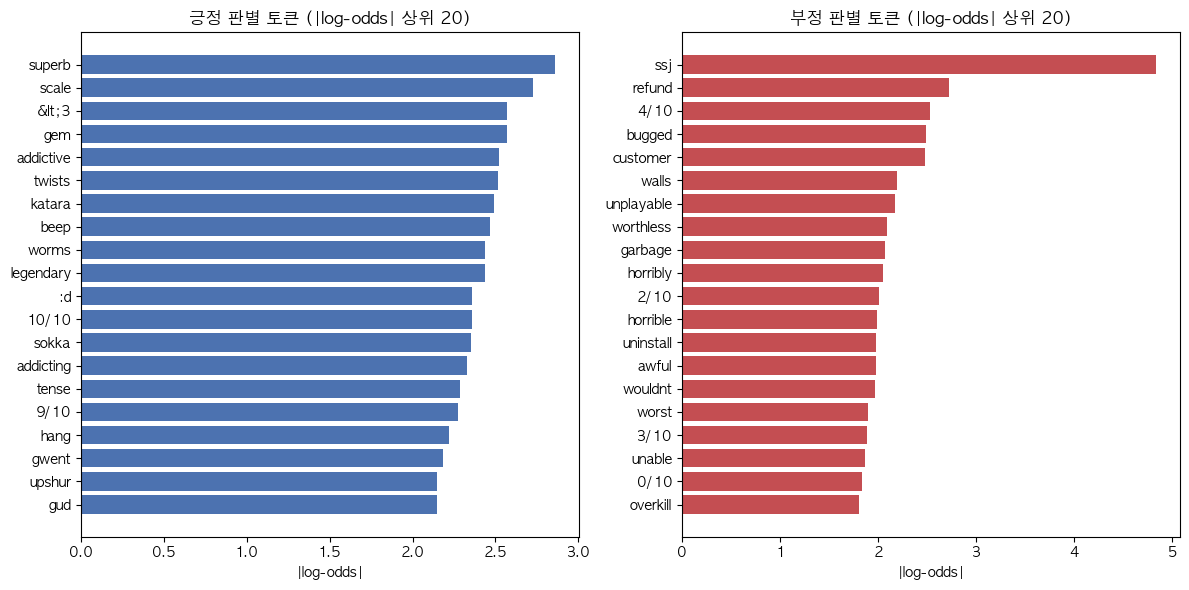

In [33]:
import numpy as np
from collections import Counter

MIN_COUNT = 20
ALPHA = 1.0

def token_counts(texts):
    return Counter(w for t in texts for w in t.lower().split() if len(w) > 1)

pos_c = token_counts(after[after["label"] == 1]["text"])
neg_c = token_counts(after[after["label"] == 0]["text"])

vocab = [w for w in set(pos_c) | set(neg_c) if pos_c[w] + neg_c[w] >= MIN_COUNT]
n_pos, n_neg, V = sum(pos_c.values()), sum(neg_c.values()), len(vocab)

logodds = pd.DataFrame({
    "token": vocab,
    "긍정 빈도": [pos_c[w] for w in vocab],
    "부정 빈도": [neg_c[w] for w in vocab],
    "log_odds": [np.log((pos_c[w] + ALPHA) / (n_pos + ALPHA * V))
                 - np.log((neg_c[w] + ALPHA) / (n_neg + ALPHA * V)) for w in vocab],
}).sort_values("log_odds", ascending=False)

top_pos = logodds.head(20)
top_neg = logodds.tail(20).iloc[::-1]
pd.concat([top_pos.assign(감성="긍정"), top_neg.assign(감성="부정")]) \
    .to_csv(OUTPUT_DIR / "02_discriminative_tokens_logodds.csv", index=False, encoding="utf-8-sig")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, (top, name, color) in zip(axes, [(top_pos, "긍정", "#4c72b0"),
                                         (top_neg, "부정", "#c44e52")]):
    ax.barh(range(len(top)), top["log_odds"].abs(), color=color)
    ax.set_yticks(range(len(top)), top["token"])
    ax.invert_yaxis()
    ax.set_title(f"{name} 판별 토큰 (|log-odds| 상위 20)")
    ax.set_xlabel("|log-odds|")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "02_discriminative_tokens_logodds.png", dpi=150, bbox_inches="tight")
plt.show()

### 관찰 노트

- `refund`, `bugged`, `unplayable`, `2/10` (부정) / `superb`, `gem`, `addictive`, `10/10` (긍정)처럼
  실제 감성 신호가 상위에 올라온다. 단순 빈도 차트에서 양쪽 1위였던 `game`은 긍/부정 빈도가
  비슷해 log-odds가 0 근처로 밀려나므로 별도 불용어 처리 없이 자연히 제외된다.
- `katara`, `sokka` 같은 **특정 게임의 캐릭터명(고유명사)**도 판별 토큰에 끼어 있는데,
  이는 감성 어휘가 아니라 2만 건 샘플에서 특정 게임의 리뷰가 한쪽 감성에 몰리며 생기는
  **샘플링 편향**이다. 샘플 크기를 키우거나 게임(app_id) 단위로 층화 샘플링하면 완화된다 —
  판별 토큰 해석 시 유의할 것.

## 분할 및 저장

In [34]:
tr, va, te = split_data(after, seed=RANDOM_SEED)
tr.to_csv(DATA_DIR / "train.csv", index=False)
va.to_csv(DATA_DIR / "val.csv", index=False)
te.to_csv(DATA_DIR / "test.csv", index=False)
print(f"train={len(tr)} val={len(va)} test={len(te)} → {DATA_DIR}")

train=11498 val=2464 test=2464 → /Users/gomuseo/Desktop/Python/review-check/data


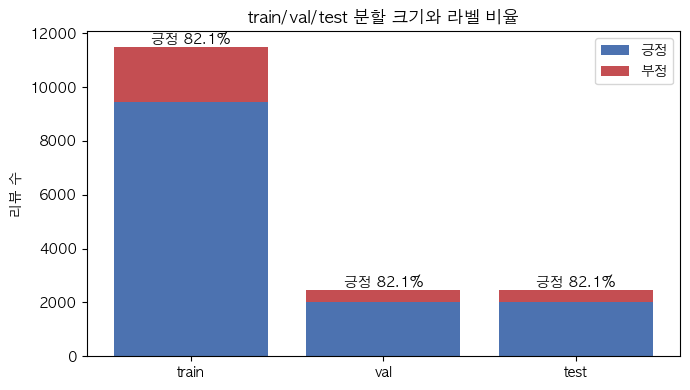

In [35]:
# 분할별 크기와 라벨 비율 (계층분할 검증)
splits = {"train": tr, "val": va, "test": te}
fig, ax = plt.subplots(figsize=(7, 4))
pos = [len(d[d["label"] == 1]) for d in splits.values()]
neg = [len(d[d["label"] == 0]) for d in splits.values()]
ax.bar(splits.keys(), pos, label="긍정", color="#4c72b0")
ax.bar(splits.keys(), neg, bottom=pos, label="부정", color="#c44e52")
for i, d in enumerate(splits.values()):
    ax.text(i, len(d), f"긍정 {d['label'].mean():.1%}", ha="center", va="bottom")
ax.set_title("train/val/test 분할 크기와 라벨 비율")
ax.set_ylabel("리뷰 수")
ax.legend()
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "02_split_label_ratio_v2.png", dpi=150, bbox_inches="tight")
plt.show()